📊 Baseball Pitching Analysis — Overview

This project analyzes MLB pitching data using Statcast to identify pitcher tendencies and classify pitching styles based on fastball velocity and usage. Using a sample dataset, we extract key variables such as pitch type, release speed, and outcomes, then engineer features to measure average fastball velocity and fastball usage percentage for each pitcher.

Pitchers are grouped into archetypes—Power Fastball, Offspeed Heavy, and Balanced—to simplify interpretation and highlight strategic differences in approach. This framework allows for scalable analysis across different time periods, enabling deeper insights into how pitching profiles evolve over a season.

The workflow follows a structured pipeline: data extraction, cleaning, feature engineering, aggregation, and classification, ensuring results are both interpretable and extensible for further analysis.

Imports
-pybaseball pip install *
-pandas
-numpy

In [8]:
from pybaseball import statcast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

TEST DATA PULL (Small Range)

In [9]:
data = statcast(start_dt="2024-04-01", end_dt="2024-04-07")

print(data.shape)
data.head()

This is a large query, it may take a moment to complete


  0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = da

(26072, 118)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
2623,CU,2024-04-07,85.2,-2.31,6.16,"Johnson, Pierce",664983,572955,field_out,hit_into_play,...,2,3.78,-0.73,0.73,36.0,21.26133,-9.620944,34.858224,44.484484,39.961796
2734,CU,2024-04-07,86.0,-2.33,6.15,"Johnson, Pierce",664983,572955,NaN,called_strike,...,2,3.52,-0.78,0.78,41.6,<NA>,<NA>,<NA>,<NA>,<NA>
2791,CU,2024-04-07,85.8,-2.27,6.2,"Johnson, Pierce",553993,572955,field_out,hit_into_play,...,1,3.49,-0.91,-0.91,42.2,14.211988,7.795369,34.318302,45.151528,27.733033
2883,CU,2024-04-07,86.5,-2.3,6.24,"Johnson, Pierce",572233,572955,single,hit_into_play,...,1,3.39,-0.9,-0.9,38.3,4.061736,9.400294,24.872673,33.739691,28.735222
3006,CU,2024-04-07,86.1,-2.18,6.16,"Johnson, Pierce",572233,572955,NaN,ball,...,1,3.51,-1.14,-1.14,40.2,<NA>,<NA>,<NA>,<NA>,<NA>


Keep Only What We Need

In [10]:
df = data[[
     'player_name',
    'game_date',
    'pitch_type',
    'release_speed',
    'events'


]].dropna()
df.sort_values(by='player_name', ascending=False)

,player_name,game_date,pitch_type,release_speed,events
1644,"Zuñiga, Guillo",2024-04-03,FF,95.8,field_out
3089,"Zuñiga, Guillo",2024-04-03,FF,96.8,field_out
3704,"Zuñiga, Guillo",2024-04-03,SI,96.4,field_out
2270,"Zuñiga, Guillo",2024-04-03,FF,96.8,field_out
2163,"Zuñiga, Guillo",2024-04-03,FF,95.2,field_out
...,...,...,...,...,...
750,"Abbott, Andrew",2024-04-07,FF,91.9,field_out
643,"Abbott, Andrew",2024-04-07,ST,81.5,field_out
543,"Abbott, Andrew",2024-04-07,FF,91.7,home_run
390,"Abbott, Andrew",2024-04-07,CH,84.2,strikeout


Define Fastball Types

In [11]:
fastballs = ['FF', 'SI', 'FC', 'FT']

Define OUT Events

In [12]:
outs = ['field_out', 'groundout', 'flyout', 'lineout']

df['is_out'] = df['events'].isin(outs).astype(int)

Calculate Pitcher Stats

In [13]:
fastball_data = df[df['pitch_type'].isin(fastballs)]
velo = fastball_data.groupby('player_name')['release_speed'].mean().reset_index()
velo.columns = ['player_name', 'avg_fastball_velo']

Calculate pitcher Stats

In [14]:
pitcher_stats = df.groupby('player_name').agg({
    'is_out': 'mean',
    'release_speed': 'mean',
    'pitch_type': lambda x: x.isin(fastballs).mean()
}).reset_index()

pitcher_stats.rename(columns={
    'is_out': 'Out Rate'
}, inplace=True)

Fastball usage %

In [15]:
total_pitches = df.groupby('player_name').size().reset_index(name='total_pitches')

fastball_counts = fastball_data.groupby('player_name').size().reset_index(name='fastball_count')

usage = pd.merge(total_pitches, fastball_counts, on='player_name', how='left').fillna(0)

usage['fastball_pct'] = usage['fastball_count'] / usage['total_pitches']
usage.sort_values(by='fastball_pct', ascending=False)

,player_name,total_pitches,fastball_count,fastball_pct
17,"Armstrong, Shawn",14,14.0,1.0
344,"Strahm, Matt",11,11.0,1.0
346,"Stratton, Hunter",10,10.0,1.0
339,"Speier, Gabe",7,7.0,1.0
269,"Pallante, Andre",6,6.0,1.0
...,...,...,...,...
40,"Borucki, Ryan",4,0.0,0.0
316,"Sborz, Josh",2,0.0,0.0
313,"Sanó, Miguel",1,0.0,0.0
397,"Yates, Kirby",3,0.0,0.0


Combine Them

In [16]:
pitcher_stats = pd.merge(velo, usage, on='player_name')
pitcher_stats.sort_values(by='avg_fastball_velo', ascending=False)

,player_name,avg_fastball_velo,total_pitches,fastball_count,fastball_pct
238,"Miller, Mason",100.9125,17,8.0,0.470588
61,"Chapman, Aroldis",99.3,6,2.0,0.333333
66,"Clase, Emmanuel",98.866667,11,6.0,0.545455
110,"Foley, Jason",98.83,11,10.0,0.909091
205,"Loáisiga, Jonathan",98.8,3,1.0,0.333333
...,...,...,...,...,...
345,"Suter, Brent",86.785714,20,14.0,0.700000
388,"Yarbrough, Ryan",85.682353,37,17.0,0.459459
63,"Cimber, Adam",85.583333,8,6.0,0.750000
286,"Raley, Brooks",85.033333,13,3.0,0.230769


Classify Pitchers

In [17]:
def classify_pitcher(row):
    if row['avg_fastball_velo'] >= 95 and row['fastball_pct'] >= 0.55:
        return 'Power Fastball'
    elif row['fastball_pct'] <= 0.45:
        return 'Offspeed Heavy'
    else:
        return 'Balanced'

pitcher_stats['archetype'] = pitcher_stats.apply(classify_pitcher, axis=1)

QUICK CHECK

In [18]:
pitcher_stats.head()
pitcher_stats['archetype'].value_counts()

,count
archetype,
Balanced,231
Offspeed Heavy,112
Power Fastball,48


Create outcome columns


In [19]:
df['is_hit'] = df['events'].isin(['single', 'double', 'triple', 'home_run']).astype(int)
df['is_strikeout'] = (df['events'] == 'strikeout').astype(int)
outs = [
    'field_out', 'force_out', 'grounded_into_double_play',
    'double_play', 'fielders_choice_out',
    'sac_fly', 'sac_bunt'
]

df['is_out'] = df['events'].isin(outs).astype(int)


AGG performance Per Pitcher

In [20]:
performance = df.groupby('player_name').agg({
    'is_hit': 'sum',
    'is_strikeout': 'sum',
    'is_out': 'sum',
    'events': 'count'
}).reset_index()

performance.columns = ['player_name', 'hits', 'strikeouts', 'outs', 'total_events']

Create Rates K rate Hit rate

In [21]:
performance['hit_rate'] = performance['hits'] / performance['total_events']
performance['k_rate'] = performance['strikeouts'] / performance['total_events']
performance['out_minus_hit'] = performance['outs'] - performance['hits']
performance['run_prevention'] = performance['out_minus_hit'] / performance['total_events']
performance['out_rate'] = performance['outs'] / performance['total_events']
performance['run_prevention'] = (performance['outs'] - performance['hits']) / performance['total_events']


Contact Quality Aggregation Damage Rate

In [22]:
performance['damage_rate'] = performance['hits'] / performance['total_events']

ADD TIME (SEASON SPLIT)

In [23]:
df['game_date'] = pd.to_datetime(df['game_date'])
df['month'] = df['game_date'].dt.month

Merge Performance

In [24]:
final_df = pd.merge(pitcher_stats, performance, on='player_name')
final_df.groupby('archetype')[['k_rate','hit_rate','out_rate']].mean()

final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        391 non-null    object 
 1   avg_fastball_velo  391 non-null    Float64
 2   total_pitches      391 non-null    int64  
 3   fastball_count     391 non-null    float64
 4   fastball_pct       391 non-null    float64
 5   archetype          391 non-null    object 
 6   hits               391 non-null    int64  
 7   strikeouts         391 non-null    int64  
 8   outs               391 non-null    int64  
 9   total_events       391 non-null    int64  
 10  hit_rate           391 non-null    float64
 11  k_rate             391 non-null    float64
 12  out_minus_hit      391 non-null    int64  
 13  run_prevention     391 non-null    float64
 14  out_rate           391 non-null    float64
 15  damage_rate        391 non-null    float64
dtypes: Float64(1), float64(7),

Define Season Buckets

In [25]:
def season_period(month):
    if month <= 5:
        return 'Early'
    elif month <= 7:
        return 'Mid'
    else:
        return 'Late'

df['season_period'] = df['month'].apply(season_period)

Plot

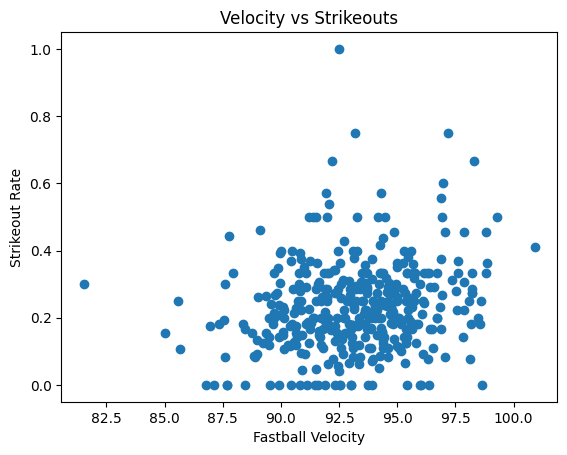

In [26]:
plt.scatter(final_df['avg_fastball_velo'], final_df['k_rate'])
plt.xlabel('Fastball Velocity')
plt.ylabel('Strikeout Rate')
plt.title('Velocity vs Strikeouts')
plt.show()

prep and download  cleanedfiles

In [27]:
final_df.to_csv('pitching_analysis.csv', index=False)
files.download('pitching_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>